In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import joblib

plt.rcParams.update({
    'figure.facecolor':  '#0d1117',
    'axes.facecolor':    '#0d1117',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'axes.titlecolor':   '#ffffff',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'text.color':        '#c9d1d9',
    'grid.color':        '#21262d',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'monospace',
})

ACCENT = '#58a6ff'
GREEN  = '#3fb950'
ORANGE = '#d29922'
RED    = '#f85149'
PURPLE = '#bc8cff'

print("✅ All imports loaded!")

✅ All imports loaded!


In [2]:
df = pd.read_csv('../data/diabetic_data_cleaned.csv')

print(f"✅ Cleaned data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df['readmitted_binary'].value_counts())

✅ Cleaned data loaded: 99,353 rows × 50 columns

Target distribution:
readmitted_binary
0    88039
1    11314
Name: count, dtype: int64


In [3]:
X = df.drop(columns=['readmitted_binary'])
y = df['readmitted_binary']

# Find any columns that still have string values
string_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"String columns found: {string_cols}")

# Fix: encode any remaining string columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in string_cols:
    print(f"  Encoding: {col} → unique values: {X[col].unique()[:5]}")
    X[col] = le.fit_transform(X[col].astype(str))

# Now convert everything to float
X = X.astype(float)

print(f"\n✅ Features (X): {X.shape[1]} columns")
print(f"✅ Target (y): {y.shape[0]:,} rows")
print(f"✅ All columns are now numeric!")

String columns found: ['glipizide-metformin']
  Encoding: glipizide-metformin → unique values: <ArrowStringArray>
['No', 'Steady']
Length: 2, dtype: str

✅ Features (X): 49 columns
✅ Target (y): 99,353 rows
✅ All columns are now numeric!


In [4]:
# Fix: ensure all columns are proper numeric types before SMOTE
X = X.astype(float)

print("Before SMOTE:")
print(f"  Class 0 (not readmitted): {(y==0).sum():,}")
print(f"  Class 1 (readmitted <30): {(y==1).sum():,}")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\nAfter SMOTE:")
print(f"  Class 0 (not readmitted): {(y_resampled==0).sum():,}")
print(f"  Class 1 (readmitted <30): {(y_resampled==1).sum():,}")
print(f"\n✅ Classes are now balanced!")

Before SMOTE:
  Class 0 (not readmitted): 88,039
  Class 1 (readmitted <30): 11,314

After SMOTE:
  Class 0 (not readmitted): 88,039
  Class 1 (readmitted <30): 88,039

✅ Classes are now balanced!


In [5]:
# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled  # keeps class ratio same in both splits
)

print(f"✅ Data split complete!")
print(f"   Training set:   {X_train.shape[0]:,} rows")
print(f"   Test set:       {X_test.shape[0]:,} rows")

✅ Data split complete!
   Training set:   140,862 rows
   Test set:       35,216 rows


In [6]:
# StandardScaler puts all numbers on the same scale
# Important for Logistic Regression especially

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled!")
print("   Mean of each feature is now ~0")
print("   Std of each feature is now ~1")

✅ Features scaled!
   Mean of each feature is now ~0
   Std of each feature is now ~1


In [7]:
print("🚀 Training models... this may take 2-3 minutes...")
print()

# Model 1: Logistic Regression
print("Training Model 1: Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("  ✅ Done!")

# Model 2: Random Forest
print("Training Model 2: Random Forest...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1  # use all CPU cores
)
rf.fit(X_train, y_train)
print("  ✅ Done!")

# Model 3: Gradient Boosting
print("Training Model 3: Gradient Boosting...")
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)
print("  ✅ Done!")

print("\n🎉 All 3 models trained!")

🚀 Training models... this may take 2-3 minutes...

Training Model 1: Logistic Regression...
  ✅ Done!
Training Model 2: Random Forest...
  ✅ Done!
Training Model 3: Gradient Boosting...
  ✅ Done!

🎉 All 3 models trained!


In [10]:
def evaluate_model(name, model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]
    
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 2),
        'AUC-ROC': round(roc_auc_score(y_test, y_prob) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall': round(recall_score(y_test, y_pred) * 100, 2),
        'F1': round(f1_score(y_test, y_pred) * 100, 2),
        'y_prob': y_prob,
        'y_pred': y_pred
    }

results = []
results.append(evaluate_model("Logistic Regression", lr, X_test_scaled, y_test))
results.append(evaluate_model("Random Forest",       rf, X_test, y_test))
results.append(evaluate_model("Gradient Boosting",   gb, X_test, y_test))

print("=" * 70)
print(f"{'Model':<25} {'Accuracy':>9} {'AUC-ROC':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("=" * 70)
for r in results:
    print(f"{r['Model']:<25} {r['Accuracy']:>8}% {r['AUC-ROC']:>8}% {r['Precision']:>9}% {r['Recall']:>7}% {r['F1']:>7}%")
print("=" * 70)

Model                      Accuracy   AUC-ROC  Precision   Recall       F1
Logistic Regression          62.15%    67.48%     63.63%   56.72%   59.98%
Random Forest                92.25%    95.34%     98.56%   85.76%   91.72%
Gradient Boosting            93.44%    95.54%     99.78%   87.08%    93.0%


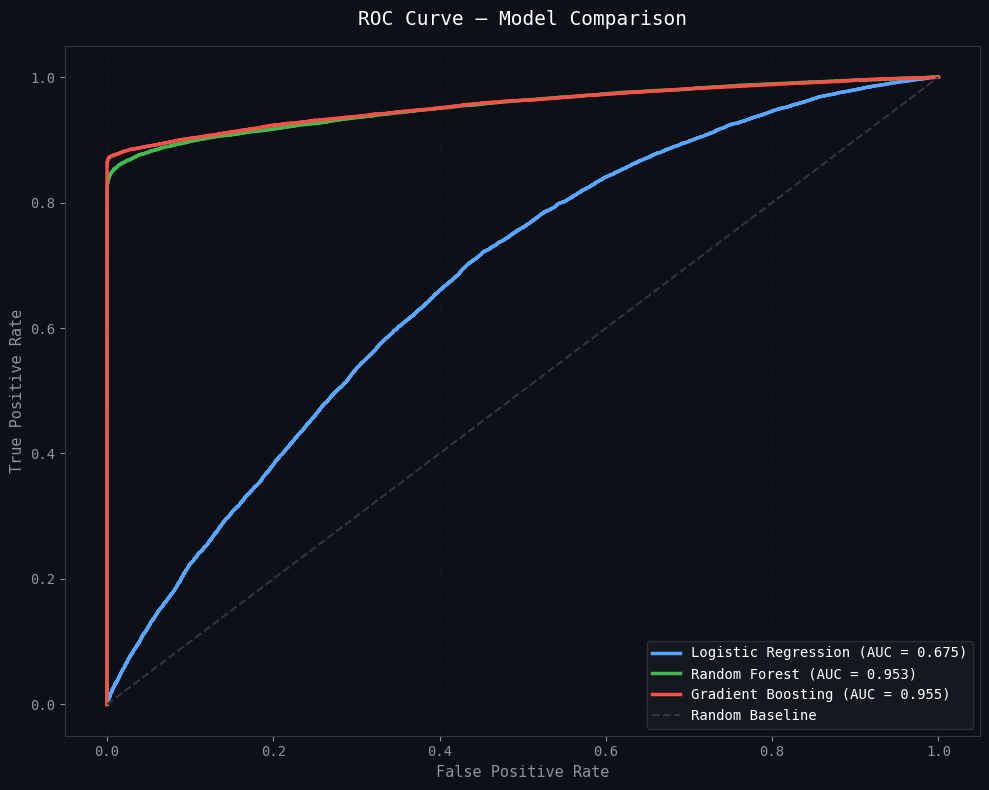

✅ ROC curve saved!


In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')

colors = [ACCENT, GREEN, RED]
model_names = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
model_probs = [r['y_prob'] for r in results]

for prob, name, color in zip(model_probs, model_names, colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {auc:.3f})')

# Diagonal = random model baseline
ax.plot([0, 1], [0, 1], color='#30363d', linestyle='--', 
        linewidth=1.5, label='Random Baseline')

ax.set_title('ROC Curve — Model Comparison', color='white', fontsize=14, pad=15)
ax.set_xlabel('False Positive Rate', color='#8b949e', fontsize=11)
ax.set_ylabel('True Positive Rate', color='#8b949e', fontsize=11)
ax.legend(facecolor='#161b22', edgecolor='#30363d', 
          labelcolor='white', fontsize=10)
ax.yaxis.grid(True, alpha=0.3)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../assets/08_roc_curve.png', 
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ ROC curve saved!")

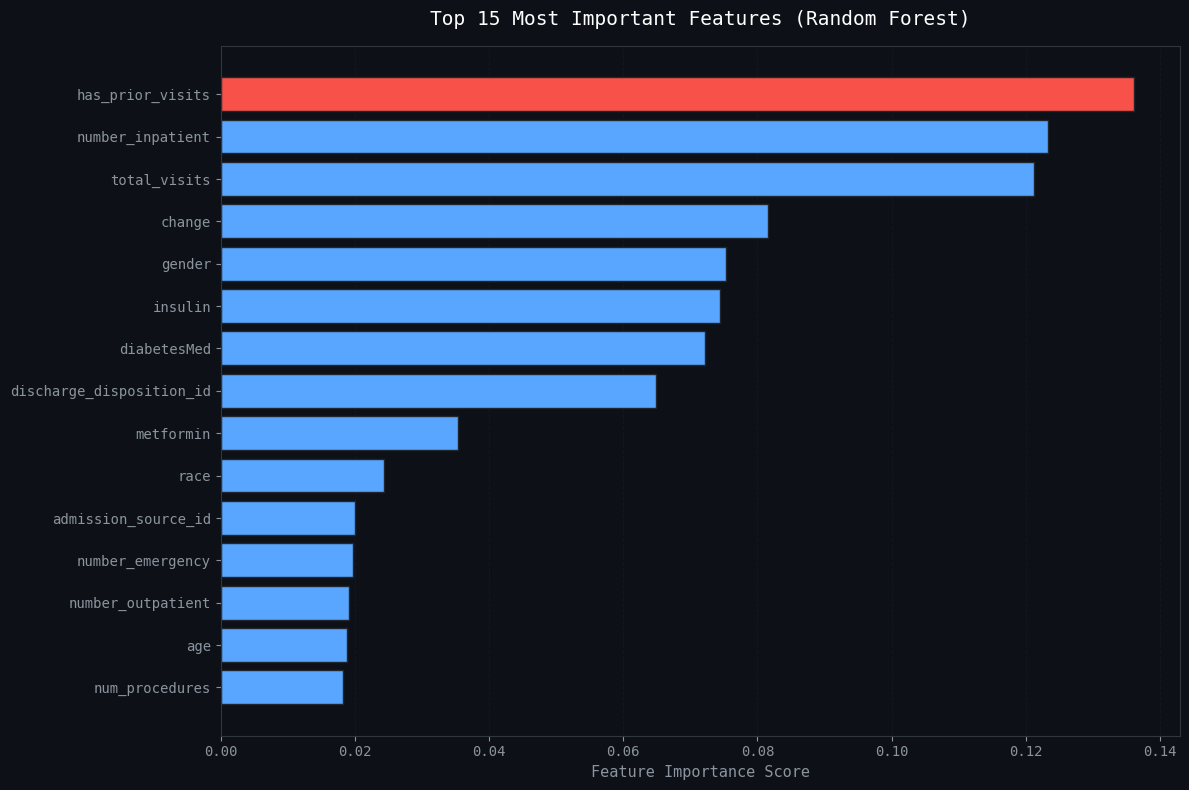

✅ Feature importance chart saved!


In [12]:
# Random Forest gives us feature importance scores
# This tells us WHICH features matter most for prediction

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0d1117')

importances = rf.feature_importances_
feat_names  = X.columns
indices     = np.argsort(importances)[::-1][:15]  # top 15

colors_bar = [RED if i == 0 else ACCENT for i in range(len(indices))]

bars = ax.barh(range(len(indices)),
               importances[indices][::-1],
               color=colors_bar[::-1],
               edgecolor='#21262d')

ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feat_names[i] for i in indices][::-1], fontsize=10)
ax.set_title('Top 15 Most Important Features (Random Forest)',
             color='white', fontsize=14, pad=15)
ax.set_xlabel('Feature Importance Score', color='#8b949e', fontsize=11)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../assets/09_feature_importance.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("✅ Feature importance chart saved!")

🏆 Best model: Gradient Boosting (AUC-ROC: 95.54%)


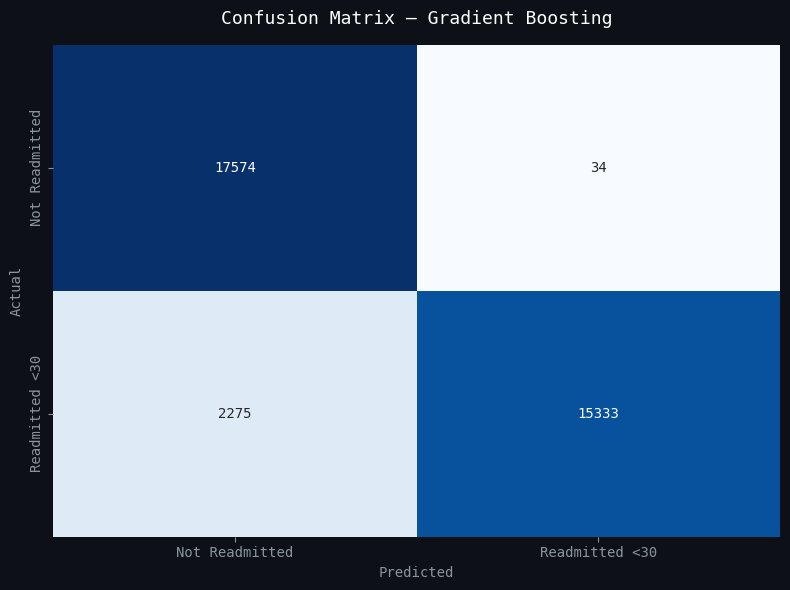

In [13]:
# Find best model by AUC-ROC
best = max(results, key=lambda x: x['AUC-ROC'])
print(f"🏆 Best model: {best['Model']} (AUC-ROC: {best['AUC-ROC']}%)")

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            ax=ax, cbar=False,
            xticklabels=['Not Readmitted', 'Readmitted <30'],
            yticklabels=['Not Readmitted', 'Readmitted <30'])

ax.set_title(f'Confusion Matrix — {best["Model"]}',
             color='white', fontsize=13, pad=15)
ax.set_xlabel('Predicted', color='#8b949e')
ax.set_ylabel('Actual', color='#8b949e')

plt.tight_layout()
plt.savefig('../assets/10_confusion_matrix.png',
            dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [14]:
# Save the best model + scaler so our Streamlit app can use them

best_name = best['Model']

if best_name == 'Gradient Boosting':
    best_model = gb
elif best_name == 'Random Forest':
    best_model = rf
else:
    best_model = lr

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')
joblib.dump(rf,         '../models/random_forest.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print(f"✅ Best model saved: {best_name}")
print(f"✅ Scaler saved")
print(f"✅ Feature names saved")
print(f"\n📁 Models folder:")
import os
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f"   {f} ({size:.1f} KB)")

✅ Best model saved: Gradient Boosting
✅ Scaler saved
✅ Feature names saved

📁 Models folder:
   best_model.pkl (454.7 KB)
   feature_names.pkl (0.8 KB)
   random_forest.pkl (6140.0 KB)
   scaler.pkl (2.7 KB)
